In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

In [52]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

In [53]:
# ── Plotting style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#3a3f55",   "axes.labelcolor": "#c8cce0",
    "xtick.color": "#8a8fa8",      "ytick.color": "#8a8fa8",
    "text.color": "#c8cce0",       "grid.color": "#2a2f45",
    "grid.linestyle": "--",        "grid.alpha": 0.5,
    "font.family": "monospace",    "axes.titlecolor": "#e0e4f5",
    "axes.titlesize": 12,          "axes.titleweight": "bold",
})
ACCENT  = "#00d4aa"
ACCENT2 = "#7b61ff"
ACCENT3 = "#ff6b6b"
PALETTE = [ACCENT, ACCENT2, ACCENT3, "#ffd166", "#06d6a0", "#118ab2",
           "#ef476f", "#26547c", "#ffe66d", "#4ecdc4", "#ff6b35", "#a8dadc"]

In [54]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.  LOAD & INSPECT DATA
# ═══════════════════════════════════════════════════════════════════════════

df = pd.read_csv("/kaggle/input/datasets/programmer3/real-time-wireless-mcs-prediction-dataset/mcs_prediction_dataset.csv")
 
print(f"\n[DATA]  Shape : {df.shape}")
print(f"[DATA]  Columns ({len(df.columns)}):")
print(f"  {list(df.columns)}\n")
print(df.head(3).to_string())
print("\n[INFO]  Data types:")
print(df.dtypes.to_string())
print("\n[INFO]  Missing values:")
print(df.isnull().sum().to_string())
print("\n[INFO]  Basic statistics:")
print(df.describe().T.to_string())


[DATA]  Shape : (5000, 15)
[DATA]  Columns (15):
  ['signal_strength', 'distance_to_tower', 'snr', 'attenuation', 'fft_0', 'fft_1', 'fft_2', 'fft_3', 'fft_4', 'fft_5', 'fft_6', 'fft_7', 'fft_8', 'fft_9', 'mcs_level']

   signal_strength  distance_to_tower        snr  attenuation     fft_0      fft_1     fft_2     fft_3     fft_4      fft_5      fft_6      fft_7      fft_8      fft_9  mcs_level
0       -73.782192           3.996992  11.209225    49.967024  8.655331  19.102628  3.613316  8.505889  4.584160   9.708170   8.368796  14.713434  13.851021   8.492702          0
1       -33.449999           4.787013   9.987363    74.674677  6.084152   6.834469  7.590946  5.499097  4.481103  13.870749  14.475434   1.299704   4.723592  15.951464          1
2       -48.760424           8.560019   5.284617    56.266678  5.124665   9.275026  5.196756  8.716861  1.882065   5.966219   5.418360   5.003535   7.380622  14.322624          1

[INFO]  Data types:
signal_strength      float64
distance_to_tow

In [55]:
# ═══════════════════════════════════════════════════════════════════════════
# 2.  PRE-PROCESSING
# ═══════════════════════════════════════════════════════════════════════════
 
# 2a. Drop exact duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicate rows.")

Removed 0 duplicate rows.


In [56]:
# 2b. Handle missing values (median imputation for numerics)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"[FILL]   Imputed '{col}' with median.")

In [57]:
# 2c. Identify target column
TARGET = [c for c in df.columns if "mcs" in c.lower()][0]
print(f"\n[TARGET] '{TARGET}' | unique values: {sorted(df[TARGET].unique())}")


[TARGET] 'mcs_level' | unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [58]:
# 2d. Feature / target split
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [59]:
# 2e. Remove constant columns
low_var = [c for c in X.columns if X[c].nunique() <= 1]
if low_var:
    X.drop(columns=low_var, inplace=True)
    print(f"Constant columns removed: {low_var}")

In [60]:

feature_names = X.columns.tolist()
print(f"\n[{len(feature_names)} features: {feature_names}")


[14 features: ['signal_strength', 'distance_to_tower', 'snr', 'attenuation', 'fft_0', 'fft_1', 'fft_2', 'fft_3', 'fft_4', 'fft_5', 'fft_6', 'fft_7', 'fft_8', 'fft_9']


In [61]:
# ═══════════════════════════════════════════════════════════════════════════
# NEW CELL: FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

def engineer_wireless_features(X):
    X = X.copy()
    feat = X.columns.tolist()
    
    snr_col   = next((c for c in feat if 'snr'  in c.lower()), None)
    rssi_col  = next((c for c in feat if 'rssi' in c.lower() or 'signal' in c.lower()), None)
    dist_col  = next((c for c in feat if 'dist' in c.lower()), None)
    noise_col = next((c for c in feat if 'noise' in c.lower()), None)

    # SNR bucketing (MCS thresholds roughly align to SNR bins)
    if snr_col:
        X['snr_bin'] = pd.cut(X[snr_col],
                               bins=[-np.inf, 0, 5, 10, 15, 20, 25, 30, np.inf],
                               labels=False)
        X['snr_squared'] = X[snr_col] ** 2
        X['snr_log']     = np.log1p(np.clip(X[snr_col], 0, None))

    # Path loss proxy
    if rssi_col and dist_col:
        X['path_loss_proxy'] = X[rssi_col] / (X[dist_col].clip(lower=0.1))
        X['link_budget']     = X[rssi_col] - X[dist_col] * 0.1

    # Noise-adjusted SNR
    if snr_col and noise_col:
        X['snr_noise_ratio'] = X[snr_col] / (X[noise_col].clip(lower=0.01))

    # Interaction: SNR × distance
    if snr_col and dist_col:
        X['snr_x_dist'] = X[snr_col] * X[dist_col]

    print(f"Features after engineering: {X.shape[1]} (was {len(feat)})")
    return X

X = engineer_wireless_features(X)
feature_names = X.columns.tolist()

# Re-split with new features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Features after engineering: 20 (was 14)


In [62]:
# 2f. 80:20 train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (4000, 20)  |  Test: (1000, 20)


In [63]:
from collections import Counter
from imblearn.over_sampling import SMOTE

print("Class distribution before SMOTE:")
print(Counter(y_train))

min_class_count = min(Counter(y_train).values())
k_neighbors     = min(5, min_class_count - 1)   # SMOTE requires k < min_class_size

if k_neighbors >= 1:
    sm = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
    X_train, y_train = sm.fit_resample(X_train, y_train)
    print(f"Class distribution after SMOTE:")
    print(Counter(y_train))
else:
    print("Skipping SMOTE — some class has only 1 sample.")

Class distribution before SMOTE:
Counter({3: 689, 1: 684, 5: 678, 0: 657, 2: 650, 4: 642})
Class distribution after SMOTE:
Counter({1: 689, 2: 689, 5: 689, 3: 689, 4: 689, 0: 689})


In [64]:
# 2g. Scaled versions (for SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

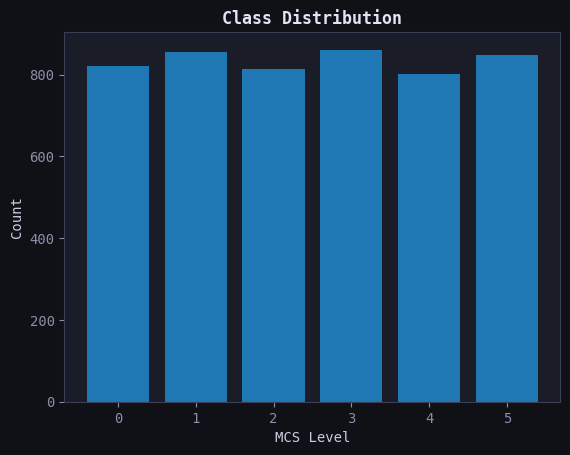

In [65]:
# ═══════════════════════════════════════════════════════════════════════════
# 3.  DATASET ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import pandas as pd

class_counts = pd.Series(y).value_counts().sort_index()

plt.figure()
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("MCS Level")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

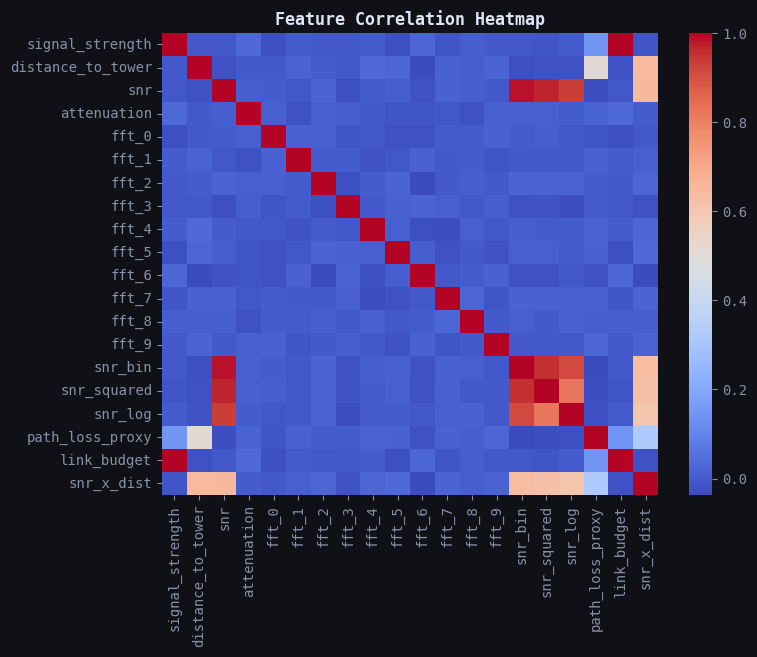

In [66]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

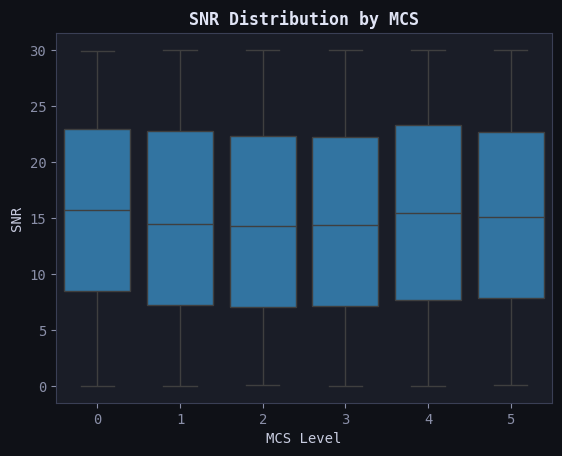

In [67]:
plt.figure()
sns.boxplot(x=y, y=X['snr'])
plt.xlabel("MCS Level")
plt.ylabel("SNR")
plt.title("SNR Distribution by MCS")
plt.show()

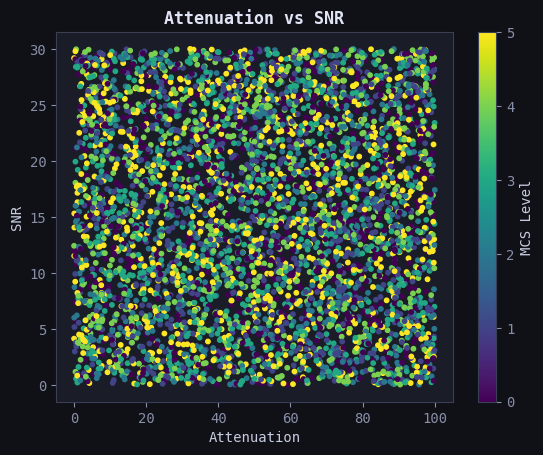

In [68]:
plt.figure()
plt.scatter(X['attenuation'], X['snr'], c=y, cmap='viridis', s=10)
plt.xlabel("Attenuation")
plt.ylabel("SNR")
plt.title("Attenuation vs SNR")
plt.colorbar(label="MCS Level")
plt.show()

In [69]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.  TRAIN MODELS
# ═══════════════════════════════════════════════════════════════════════════

# models = {
#     "Decision Tree":     DecisionTreeClassifier(random_state=SEED),
#     "Random Forest":     RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
#     "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, random_state=SEED),
#     "SVM":               SVC(kernel="rbf", C=10, gamma="scale", random_state=SEED),
# }


from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

n_classes = len(np.unique(y))

models = {
    "Random Forest":  RandomForestClassifier(n_estimators=300, random_state=SEED,
                                              n_jobs=-1, class_weight='balanced'),
    "XGBoost":        XGBClassifier(n_estimators=300, learning_rate=0.05,
                                    max_depth=6, subsample=0.8,
                                    colsample_bytree=0.8, use_label_encoder=False,
                                    eval_metric='mlogloss', random_state=SEED,
                                    n_jobs=-1),
    "LightGBM":       LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                     num_leaves=63, subsample=0.8,
                                     colsample_bytree=0.8, class_weight='balanced',
                                     random_state=SEED, n_jobs=-1, verbose=-1),
}


results = {}
for name, model in models.items():
    Xtr = X_train_sc if name == "SVM" else X_train
    Xte = X_test_sc  if name == "SVM" else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")
    cv  = cross_val_score(model, Xtr, y_train, cv=5, scoring="accuracy").mean()
    results[name] = {"acc": acc, "f1": f1, "cv": cv, "y_pred": y_pred}
    print(f"  {name:<22}  Acc={acc:.4f}  F1={f1:.4f}  CV={cv:.4f}")
 

  Random Forest           Acc=0.1610  F1=0.1608  CV=0.1945
  XGBoost                 Acc=0.1630  F1=0.1631  CV=0.1955
  LightGBM                Acc=0.1600  F1=0.1591  CV=0.2008


In [70]:
from sklearn.metrics import classification_report

print("\n" + "="*60)
print(" CLASSIFICATION REPORTS (ALL MODELS)")
print("="*60)

classes = sorted(np.unique(y))

for name, res in results.items():
    print(f"\n🔹 {name}")
    print("-"*50)
    
    print(classification_report(
        y_test,
        res["y_pred"],
        labels=classes,
        target_names=[str(c) for c in classes],
        zero_division=0
    ))


 CLASSIFICATION REPORTS (ALL MODELS)

🔹 Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.15      0.15      0.15       165
           1       0.16      0.16      0.16       171
           2       0.17      0.17      0.17       163
           3       0.17      0.19      0.18       172
           4       0.15      0.14      0.14       160
           5       0.17      0.16      0.16       169

    accuracy                           0.16      1000
   macro avg       0.16      0.16      0.16      1000
weighted avg       0.16      0.16      0.16      1000


🔹 XGBoost
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.17      0.20      0.19       165
           1       0.17      0.16      0.17       171
           2       0.18      0.17      0.17       163
           3       0.18      0.16      0.17       172
           4      

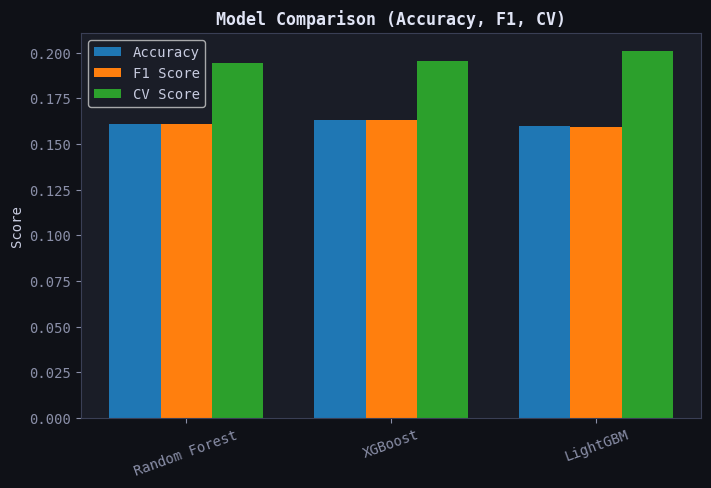

In [71]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.  MODELS COMPARISON
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

model_names = list(results.keys())

acc_vals = [results[m]["acc"] for m in model_names]
f1_vals  = [results[m]["f1"]  for m in model_names]
cv_vals  = [results[m]["cv"]  for m in model_names]

x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, acc_vals, width, label='Accuracy')
plt.bar(x,         f1_vals,  width, label='F1 Score')
plt.bar(x + width, cv_vals,  width, label='CV Score')

plt.xticks(x, model_names, rotation=20)
plt.ylabel("Score")
plt.title("Model Comparison (Accuracy, F1, CV)")
plt.legend()

plt.show()

In [72]:
# ═══════════════════════════════════════════════════════════════════════════
# DATASET INTEGRITY CHECK
# ═══════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, chi2_contingency
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("/kaggle/input/datasets/programmer3/real-time-wireless-mcs-prediction-dataset/mcs_prediction_dataset.csv")
TARGET = "mcs_level"
features = [c for c in df.columns if c != TARGET]

print("=" * 60)

# ── 1. Is the target randomly shuffled vs features? ──────────────────────
print("\n[TEST 1] Spearman correlation (each feature vs target):")
for col in features:
    r, p = spearmanr(df[col], df[TARGET])
    sig = "*** SIGNAL" if p < 0.01 and abs(r) > 0.05 else "noise"
    print(f"  {col:<25}  r={r:+.4f}  p={p:.4f}  {sig}")

# ── 2. Shuffle test — if shuffling target doesn't hurt, signal = zero ─────
print("\n[TEST 2] Shuffle test:")
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df[features]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
real_acc = accuracy_score(y_test, rf.predict(X_test))

shuffle_accs = []
for seed in range(10):
    y_shuffled = y_train.sample(frac=1, random_state=seed).reset_index(drop=True)
    rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf2.fit(X_train, y_shuffled)
    shuffle_accs.append(accuracy_score(y_test, rf2.predict(X_test)))

print(f"  Real target accuracy    : {real_acc:.4f}")
print(f"  Shuffled target avg     : {np.mean(shuffle_accs):.4f}  ± {np.std(shuffle_accs):.4f}")
if abs(real_acc - np.mean(shuffle_accs)) < 0.01:
    print("  VERDICT: ❌ Real = Shuffled → target is INDEPENDENT of features")
else:
    print("  VERDICT: ✅ Real > Shuffled → some signal exists")

# ── 3. Are features themselves just noise? ───────────────────────────────
print("\n[TEST 3] Feature statistics:")
print(df[features].describe().T[["mean","std","min","max"]].to_string())

# ── 4. Is target correlated with ROW INDEX? (data generation artifact) ───
print("\n[TEST 4] Target vs row index correlation:")
r, p = spearmanr(np.arange(len(df)), df[TARGET])
print(f"  r={r:+.4f}  p={p:.4f}")
if p < 0.01:
    print("  ⚠️  Target correlates with row order — data may be sorted/synthetic")

# ── 5. Chi-square: are any feature bins associated with target? ───────────
print("\n[TEST 5] Chi-square (binned features vs target):")
for col in features[:5]:
    binned = pd.cut(df[col], bins=6, labels=False)
    ct = pd.crosstab(binned, df[TARGET])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = "*** ASSOCIATED" if p < 0.01 else "independent"
    print(f"  {col:<25}  chi2={chi2:.1f}  p={p:.4f}  {sig}")

print("\n" + "=" * 60)


[TEST 1] Spearman correlation (each feature vs target):
  signal_strength            r=-0.0075  p=0.5943  noise
  distance_to_tower          r=-0.0156  p=0.2706  noise
  snr                        r=-0.0001  p=0.9916  noise
  attenuation                r=-0.0259  p=0.0671  noise
  fft_0                      r=+0.0239  p=0.0906  noise
  fft_1                      r=+0.0137  p=0.3318  noise
  fft_2                      r=-0.0021  p=0.8838  noise
  fft_3                      r=-0.0288  p=0.0419  noise
  fft_4                      r=-0.0243  p=0.0855  noise
  fft_5                      r=+0.0067  p=0.6350  noise
  fft_6                      r=-0.0109  p=0.4411  noise
  fft_7                      r=-0.0105  p=0.4566  noise
  fft_8                      r=-0.0253  p=0.0732  noise
  fft_9                      r=-0.0096  p=0.4962  noise

[TEST 2] Shuffle test:
  Real target accuracy    : 0.1740
  Shuffled target avg     : 0.1704  ± 0.0065
  VERDICT: ❌ Real = Shuffled → target is INDEPENDENT of